# Load the data

In [1]:
import numpy as np
import pandas as pd

alcohol_use_data = pd.read_csv("https://raw.githubusercontent.com/AngeloKarugo/ADARP_Dataset/refs/heads/master/Participant%20TLFB.csv")
alcohol_use_data['drink_count'] = alcohol_use_data['drinkCount']
alcohol_use_data['patient_id'] = alcohol_use_data['patientId']
alcohol_use_data = alcohol_use_data.drop(columns=['patientId', 'drinkCount'])

sensor_data = pd.read_csv("https://raw.githubusercontent.com/AngeloKarugo/ADARP_Dataset/refs/heads/master/allPatientsSensorData.csv")
sensor_data["patient_id"] = sensor_data["participantName"].str.strip("Part ")

sensor_data = sensor_data.drop(columns=['participantName'])

# Convert the 'timestamp' column to datetime objects before setting it as the index
sensor_data['timestamp'] = pd.to_datetime(sensor_data['timestamp'])

sensor_data.drop("Unnamed: 0", axis=1, inplace=True)

sensor_data['date'] = pd.to_datetime(sensor_data["timestamp"].dt.date)

# lag drink date by 1 day
alcohol_use_data["date"] = pd.to_datetime(alcohol_use_data["date"], dayfirst=True) - pd.Timedelta(days=1)

merged_data = pd.merge(sensor_data, alcohol_use_data, on=["patient_id",'date'], how='left')

merged_data.fillna({"drink_count": 0},inplace=True)

merged_data['drank_alcohol'] = merged_data['drink_count'] > 0

merged_data = merged_data.set_index("timestamp")

numeric_cols = sensor_data.select_dtypes(include=['number', 'bool']).columns.tolist()

sensor_data = merged_data.groupby('patient_id').resample('10min').mean()

sensor_data = sensor_data.reset_index().set_index('timestamp')

sensor_data.dropna(inplace=True)

sensor_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9153 entries, 2019-04-26 18:50:00 to 2020-02-18 05:30:00
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   patient_id       9153 non-null   object        
 1   acc_magnitude    9153 non-null   float64       
 2   eda_value        9153 non-null   float64       
 3   temp_value       9153 non-null   float64       
 4   ibi_rmssd_value  9153 non-null   float64       
 5   date             9153 non-null   datetime64[ns]
 6   drink_count      9153 non-null   float64       
 7   drank_alcohol    9153 non-null   float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 643.6+ KB


## Data visualisation

Total: 179
Days: 4


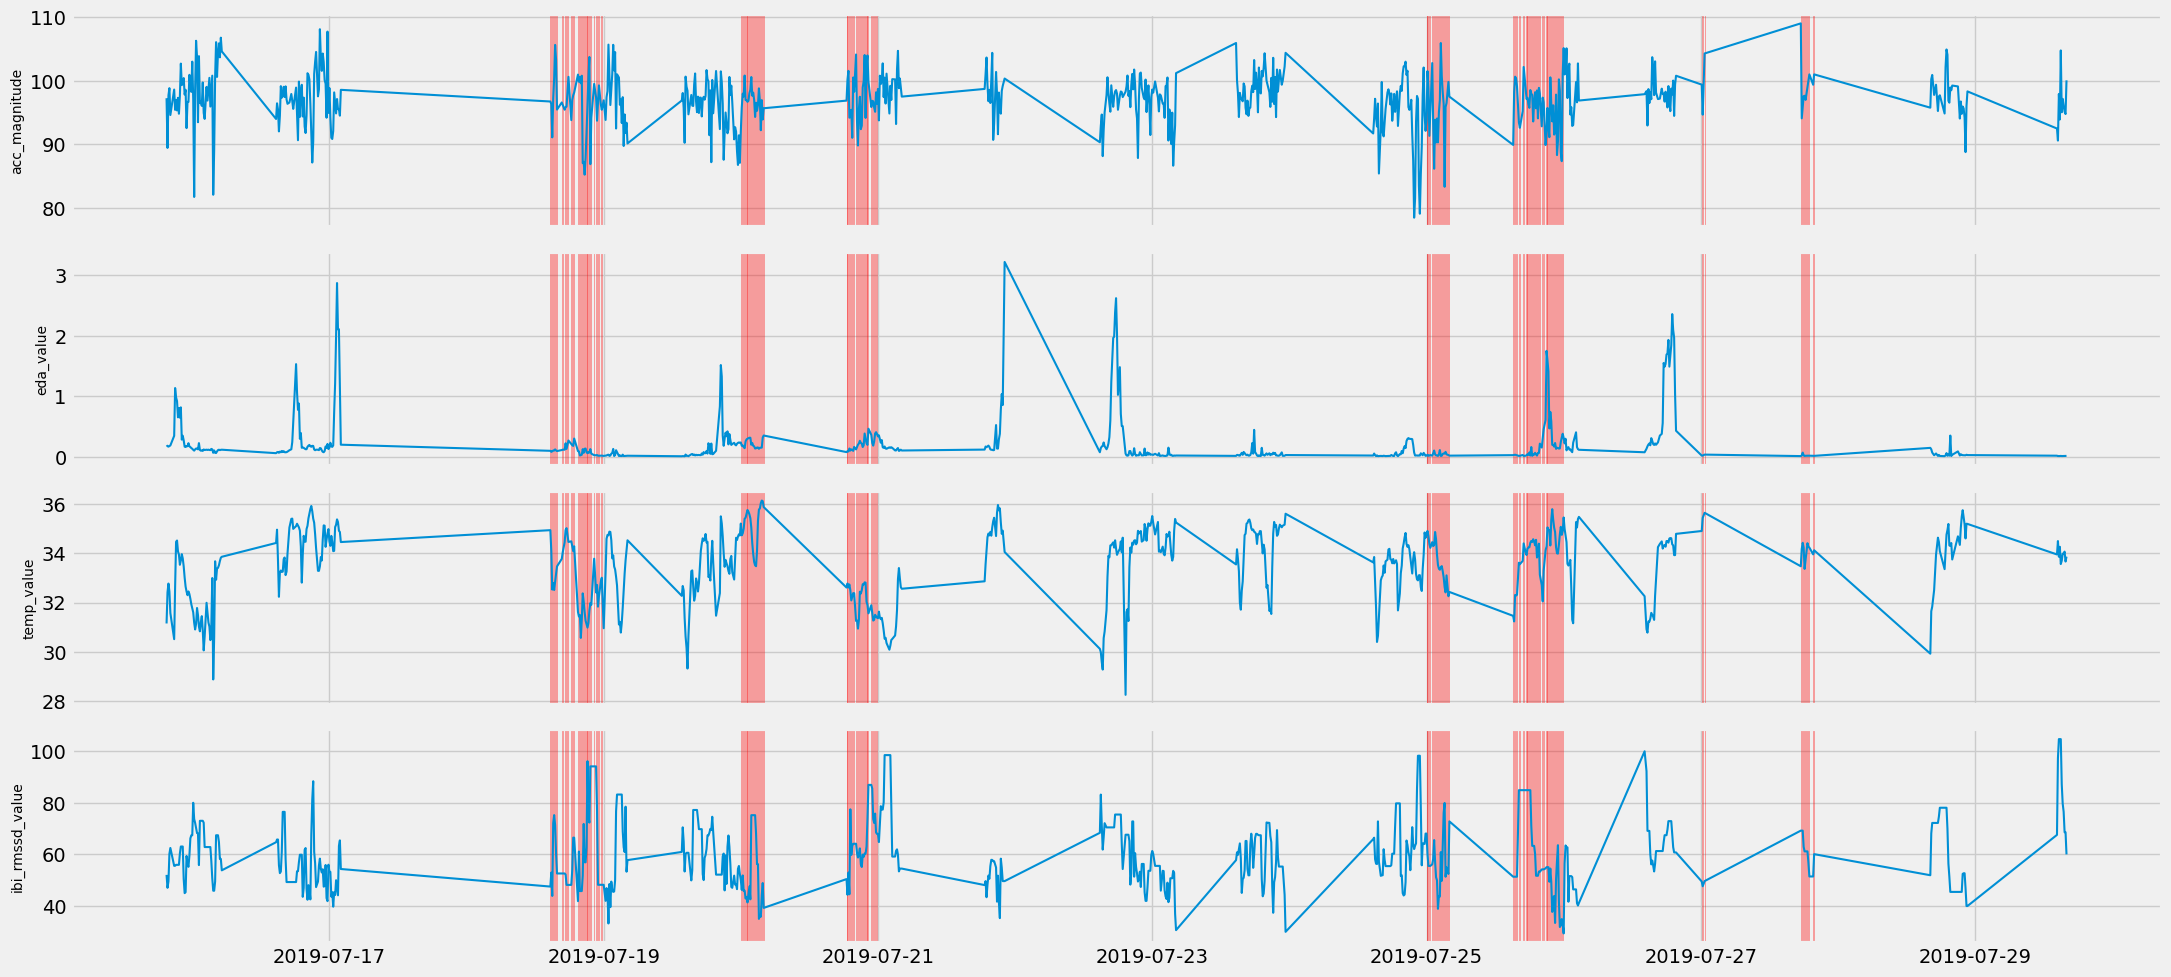

In [2]:
import matplotlib.pyplot as plt

participant_data = sensor_data[sensor_data["patient_id"] == "104C"]

plt.style.use('fivethirtyeight')

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(22,10),
    sharex=True,
)

# Define the columns to be plotted
columns_to_plot = [col for col in participant_data.columns if col not in ['patient_id', 'drink_count', 'drank_alcohol', 'date']]

# Highlight periods where 'drank_alcohol' is True
drank_periods = participant_data[participant_data['drank_alcohol'] == True]

print(f"Total: {len(drank_periods)}")
print(f"Days: {len(drank_periods.groupby('date'))}")

# Plot each column on a separate subplot
# Use enumerate on the columns_to_plot list to ensure i corresponds to the axis index
for i, col in enumerate(columns_to_plot):
    axes[i].plot(participant_data.index, participant_data[col], linewidth=1.5)
    axes[i].set_ylabel(col, fontsize=10)

    if not drank_periods.empty:
      start_time = None
      for j in range(len(drank_periods)):
        if start_time is None:
            start_time = drank_periods.index[j]
        # If the next index is not consecutive or it's the last element
        if j == len(drank_periods) - 1 or (drank_periods.index[j+1] - drank_periods.index[j]).total_seconds() > 1:
            end_time = drank_periods.index[j]
            axes[i].axvspan(start_time, end_time, color='red', alpha=0.5)
            start_time = None

plt.tight_layout()
plt.show()

# Model training and evaluation



In [3]:
from sklearn.model_selection import StratifiedGroupKFold

feature_cols = ['acc_magnitude', 'ibi_rmssd_value', "eda_value", "temp_value"]
label_col = 'drank_alcohol'
seq_len = 72
n_splits = 5

cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=32)

## XG Boost model

In [4]:
from sklearn.metrics import classification_report, recall_score
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler

df = sensor_data.copy()

def create_flattened_features(df, feature_cols, label_col, seq_len=30):
    X, y, patient_ids_list = [], [], []

    for patient_id in df['patient_id'].unique():
        patient_df = df[df['patient_id'] == patient_id].copy()

        # Ensure patient_df has enough data for at least one sequence
        if len(patient_df) < seq_len:
            continue

        for i in range(len(patient_df) - seq_len + 1): # Corrected range for windowing
            window = patient_df.iloc[i:i+seq_len]

            features = []

            for col in feature_cols:
                # Add existing statistical features
                features += [
                    window[col].mean(),
                    window[col].std(),
                    window[col].min(),
                    window[col].max(),
                    window[col].median()
                ]

                # Calculate the 'change' feature
                # For each value in the window, subtract the mean of preceding values
                # Handle the case where there are no preceding values (e.g., the first value)
                change_values = []

                for j in range(len(window)):
                    current_value = window[col].iloc[j]
                    preceding_values = window[col].iloc[:j] # Values from start of window up to (but not including) current_value

                    if len(preceding_values) > 0:
                        change = current_value - preceding_values.mean()
                    else:
                        # For the first value, there are no preceding values.
                        change = 0

                    change_values.append(change)

                # Add statistical summaries of these 'change' values as features
                if len(change_values) > 0:
                    change_series = pd.Series(change_values)
                    features += [
                        change_series.mean(),
                    ]
                else:
                    # If for some reason change_values is empty (shouldn't happen with seq_len > 0)
                    features += [0] * 5 # Add zeros for all change features

            X.append(features)
            y.append(window[label_col].any())
            patient_ids_list.append(patient_id)

    return np.array(X), np.array(y).astype(int), np.array(patient_ids_list)

# Create patient-level labels for stratification
grouped = df.groupby('patient_id')
patient_labels = {pid: int(grouped.get_group(pid)[label_col].any()) for pid in df['patient_id'].unique()}
pids = np.array(list(patient_labels.keys()))
labels = np.array(list(patient_labels.values()))

xgb_recalls = []
xgb_reports = []

for fold, (train_idx, test_idx) in enumerate(cv.split(pids, labels, groups=pids)):
    print(f"\n=== Fold {fold+1} ===")
    print(f"Train: {pids[train_idx]}")
    print(f"Test: {pids[test_idx]}")

    train_pids, test_pids = pids[train_idx], pids[test_idx]

    df_train = df[df['patient_id'].isin(train_pids)].copy()
    df_test = df[df['patient_id'].isin(test_pids)].copy()

    # Oversample minority class
    df_train_pos = df_train[df_train[label_col] == True]
    df_train_neg = df_train[df_train[label_col] == False]
    df_train_pos_oversampled = resample(df_train_pos, replace=True, n_samples=len(df_train_neg), random_state=42)
    df_train_balanced = pd.concat([df_train_neg, df_train_pos_oversampled]).sort_index()

    # Scaling
    scaler = StandardScaler()
    df_train_balanced[feature_cols] = scaler.fit_transform(df_train_balanced[feature_cols])
    df_test[feature_cols] = scaler.transform(df_test[feature_cols])

    # Feature extraction
    X_train, y_train, _ = create_flattened_features(df_train_balanced, feature_cols, label_col, seq_len)
    X_test, y_test, _ = create_flattened_features(df_test, feature_cols, label_col, seq_len)

    # XGBoost model
    model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = (model.predict_proba(X_test)[:, 1] > 0.5).astype(int)

    classification_report_dict = classification_report(y_test, y_pred,zero_division=1,output_dict=True)

    xgb_reports.append(classification_report_dict);

    print(classification_report(y_test, y_pred,zero_division=1))

    recall = recall_score(y_test, y_pred)
    xgb_recalls.append(recall)
    print(f"Fold {fold+1} Recall: {recall:.4f}")

print(f"\n--- Aggregated Cross-Validation Results ({n_splits} Folds) ---")
print(f"\nAverage minotiry class recall across {n_splits} folds for XGB: {np.mean(xgb_recalls):.4f} (+/- {np.std(xgb_recalls):.4f})")

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:1023: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(



=== Fold 1 ===
Train: ['101C' '104C' '105C' '106C' '107C' '109C' '110C' '111C' '112C']
Test: ['102C' '108C']
              precision    recall  f1-score   support

           0       0.92      0.85      0.88      1348
           1       0.20      0.35      0.26       147

    accuracy                           0.80      1495
   macro avg       0.56      0.60      0.57      1495
weighted avg       0.85      0.80      0.82      1495

Fold 1 Recall: 0.3537

=== Fold 2 ===
Train: ['101C' '102C' '105C' '106C' '107C' '108C' '110C' '111C']
Test: ['104C' '109C' '112C']
              precision    recall  f1-score   support

           0       0.35      0.57      0.43       885
           1       0.33      0.16      0.22      1136

    accuracy                           0.34      2021
   macro avg       0.34      0.37      0.32      2021
weighted avg       0.34      0.34      0.31      2021

Fold 2 Recall: 0.1620

=== Fold 3 ===
Train: ['101C' '102C' '104C' '106C' '107C' '108C' '109C' '111C' '1

## LSTM model

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold # Use StratifiedGroupKFold
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.metrics import classification_report, recall_score

# Generate Sequences
def create_sequences(df, feature_cols, label_col, seq_len):
    X, y = [], []

    for i in range(len(df) - seq_len):

        window = df.iloc[i:i+seq_len]

        if len(window['patient_id'].unique()) > 1:
            continue # skip across-patient sequences

        X.append(window[feature_cols].values)

        y.append(window[label_col].any()) # mark if drank at any timestep in window

    return np.array(X), np.array(y)

df = sensor_data.copy()

# --- Prepare data for Group Cross-Validation ---
# First, collect all unique patient IDs
all_patient_ids = df['patient_id'].unique()

# Get a label for each patient for stratification (did this patient ever drink?)
# This helps ensure each fold has a balanced representation of "drinking patients" vs "non-drinking patients"
patient_drinking_status = {pid: int(df[df['patient_id'] == pid]['drank_alcohol'].any()) for pid in all_patient_ids}
patient_labels_for_stratification = np.array([patient_drinking_status[pid] for pid in all_patient_ids])

# Initialize StratifiedGroupKFold
# It shuffles groups (patients) and tries to balance the 'y' distribution in each fold
gkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=32)

lstm_recall_scores = []
lstm_reports = []

# --- Cross-Validation Loop ---
# Iterate over splits, getting indices of patients for train and validation sets
for fold_idx, (train_patient_indices, val_patient_indices) in enumerate(gkf.split(all_patient_ids, patient_labels_for_stratification, groups=all_patient_ids)):
    print(f"\n=== Fold {fold_idx+1} ===")

    # Get the actual patient IDs for this fold
    train_pids_fold = all_patient_ids[train_patient_indices]
    val_pids_fold = all_patient_ids[val_patient_indices]

    print(f"Train: {train_pids_fold}")
    print(f"Test: {val_pids_fold}")

    # Filter the main DataFrame into training and validation sets for this fold
    df_train_fold = df[df['patient_id'].isin(train_pids_fold)].copy()
    df_val_fold = df[df['patient_id'].isin(val_pids_fold)].copy()

    # --- Oversample Minority Class in Training for this fold ---
    df_train_pos = df_train_fold[df_train_fold['drank_alcohol'] == True]
    df_train_neg = df_train_fold[df_train_fold['drank_alcohol'] == False]

    if len(df_train_pos) > 0 and len(df_train_neg) > 0: # Ensure both classes exist in train
        df_train_pos_oversampled = resample(
            df_train_pos,
            replace=True,
            n_samples=len(df_train_neg),
            random_state=42
        )
        df_train_balanced_fold = pd.concat([df_train_neg, df_train_pos_oversampled]).sort_index()
    else:
        print(f"Warning: Fold {fold_idx+1} training set missing one class, skipping oversampling. Using original training data.")
        df_train_balanced_fold = df_train_fold.copy()

    # --- Preprocessing & Scaling (FIT ON TRAIN, TRANSFORM ON TRAIN & VAL) ---
    scaler = StandardScaler()
    df_train_balanced_fold[feature_cols] = scaler.fit_transform(df_train_balanced_fold[feature_cols])
    df_val_fold[feature_cols] = scaler.transform(df_val_fold[feature_cols])

    # --- Generate Sequences for this fold ---
    X_train_fold, y_train_fold = create_sequences(df_train_balanced_fold, feature_cols, label_col, seq_len)
    X_val_fold, y_val_fold = create_sequences(df_val_fold, feature_cols, label_col, seq_len)

    # --- Model Definition (RE-INITIALIZE FOR EACH FOLD) ---
    # This ensures each fold starts with fresh, untrained weights
    model = Sequential([
        Input(shape=(seq_len, len(feature_cols))),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    # Compile & Train
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
    )

    history = model.fit(
        X_train_fold, y_train_fold,
        validation_split=0.2,
        epochs=15,
        batch_size=64,
        verbose=0
    )

    # --- Evaluate Model on the Validation Set of the current fold ---
    y_pred_prob_fold = model.predict(X_val_fold).flatten()
    y_pred_fold = (y_pred_prob_fold > 0.5).astype(int)

    # Get classification report for this fold
    report_dict = classification_report(y_val_fold.astype(int), y_pred_fold, output_dict=True, zero_division=1)
    recall_minority_fold = report_dict['1']['recall'] if '1' in report_dict else 0.0 # Handle case where class 1 might be missing in a fold's pred
    lstm_recall_scores.append(recall_minority_fold)
    lstm_reports.append(report_dict)

    print(f"Fold {fold_idx + 1} Minority Class recall: {recall_minority_fold:.4f}")
    print(classification_report(y_val_fold.astype(int), y_pred_fold,zero_division=1))

# --- Aggregate Results Across All Folds ---
if lstm_recall_scores:
    mean_recall_minority = np.mean(lstm_recall_scores)
    std_recall_minority = np.std(lstm_recall_scores)

    print(f"\n--- Aggregated Cross-Validation Results ({n_splits} Folds) ---")
    print(f"Average minority class recall across {n_splits} folds for LSTM: {mean_recall_minority:.4f} (+/- {std_recall_minority:.4f})")

else:
    print("\nNo successful folds were completed for aggregation.")

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:1023: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(



=== Fold 1 ===
Train: ['101C' '104C' '105C' '106C' '107C' '109C' '110C' '111C' '112C']
Test: ['102C' '108C']
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Fold 1 Minority Class recall: 0.8299
              precision    recall  f1-score   support

           0       0.96      0.46      0.62      1347
           1       0.14      0.83      0.24       147

    accuracy                           0.49      1494
   macro avg       0.55      0.64      0.43      1494
weighted avg       0.88      0.49      0.58      1494


=== Fold 2 ===
Train: ['101C' '102C' '105C' '106C' '107C' '108C' '110C' '111C']
Test: ['104C' '109C' '112C']
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Fold 2 Minority Class recall: 0.2896
              precision    recall  f1-score   support

           0       0.21      0.24      0.22       884
           1       0.33      0.29      0.31      1136

    accuracy                           0.27      2020
   macro avg       0.27      0.26      0.26      2020
weighted avg       0.27    

# Results analysis

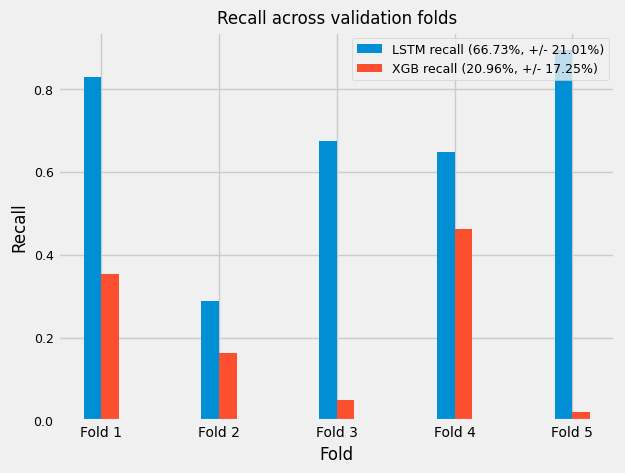

In [9]:
import matplotlib.pyplot as plt

folds = [f"Fold {i}" for i in range(1, n_splits + 1)]

index = np.arange(len(folds))
bar_width = 0.15

fig, ax = plt.subplots()

lstm = ax.bar(index, lstm_recall_scores, bar_width,
                label=f"LSTM recall ({(np.mean(lstm_recall_scores) * 100):.2f}%, +/- {(np.std(lstm_recall_scores) * 100):.2f}%)")

winter = ax.bar(index+bar_width, xgb_recalls,
                 bar_width, label=f"XGB recall ({(np.mean(xgb_recalls) * 100):.2f}%, +/- {(np.std(xgb_recalls) * 100):.2f}%)")

ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('Recall', fontsize=12)
ax.set_title('Recall across validation folds', fontsize=12)
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(folds, fontsize=10)
ax.tick_params(axis='y', labelsize=9)

ax.legend(fontsize=9, loc='upper right')

plt.show()